# Banker's Wrapped — Demo Runbook

Interactive walkthrough of the full pipeline against multiple synthetic datasets.

**Target environment**

| Setting | Value |
| --- | --- |
| Production API | `https://bankers-wrapped-api-production.up.railway.app` (default) |
| Frontend (Vercel) | `https://bankers-wrapped.arjunganesh.dev` |
| Local override | `export BANKERS_WRAPPED_API_URL=http://127.0.0.1:8000` |

**Prerequisites:** `pip install httpx matplotlib` (already in the project venv). No local backend required.

---

## How to use this notebook

Always run **Setup** (cells 2–4) first. Then pick one or more optional scenarios:

| Scenario | API cost | Time | When to run |
| --- | --- | --- | --- |
| A — Financial Builder (Jan 2026) | Yes — LLM + 5 images + TTS | ~2–3 min | Full end-to-end demo |
| B — Financial Explorer (Q4 2025) | Yes — LLM + 5 images + TTS | ~2–3 min | Full end-to-end demo |
| C — Pre-generated demo session | **None** — fetch from B2 only | <5 s | Show output without cost |

Since v1.6.0 the 5 scene images generate **in parallel**, so a full run is ~2–3 min (was ~4–5 min sequential).

Analysis cells (comparison chart, timing chart, B2 inspection) run after any scenario.

---
## Setup  *(run first — required by all scenarios)*

In [1]:
import json
import os
import time
from pathlib import Path

import httpx

# Default: production Railway backend.
# Override locally: export BANKERS_WRAPPED_API_URL=http://127.0.0.1:8000
BASE_URL = os.environ.get(
    "BANKERS_WRAPPED_API_URL",
    "https://bankers-wrapped-api-production.up.railway.app",
).rstrip("/")

FRONTEND_URL = "https://bankers-wrapped.arjunganesh.dev"
SYNTHETIC = Path("../data/synthetic")

# Collects results from whichever scenarios are run
results: dict[str, dict] = {}  # keys: "builder", "explorer", "demo"

print(f"Backend  : {BASE_URL}")
print(f"Frontend : {FRONTEND_URL}")
print(f"Synthetic: {SYNTHETIC.resolve()}")

Backend  : https://bankers-wrapped-api-production.up.railway.app
Frontend : https://bankers-wrapped.vercel.app
Synthetic: C:\ws\bankers-wrapped\data\synthetic


### Smoke test — verify backend is reachable

In [2]:
r = httpx.get(f"{BASE_URL}/api/v1/health")
data = r.json()
assert r.status_code == 200, f"Health check failed: {r.status_code}"
print(f"Status  : {data['status']}")
print(f"Version : {data.get('version', 'n/a')}")
print("Backend is ready.")

Status  : ok
Version : 1.0.0
Backend is ready.


### Helper functions

In [3]:
def run_pipeline(csv_path: Path, label: str, poll_timeout: int = 420) -> dict:
    """POST a CSV, then poll until the background pipeline completes.

    The API returns 202 + {session_id} and runs the 4-agent pipeline in the
    background. GET /recap/{id} returns 404 until it's done, then the full recap.
    """
    print(f"Running pipeline for {label} ({csv_path.name}) ...")
    t0 = time.time()
    with open(csv_path, "rb") as f:
        r = httpx.post(
            f"{BASE_URL}/api/v1/recap/generate",
            files={"file": (csv_path.name, f, "text/csv")},
            timeout=60,
        )
    if r.status_code == 429:
        raise RuntimeError("Rate limited (5 uploads/hour/IP). Wait an hour, or use Scenario C.")
    r.raise_for_status()
    session_id = r.json()["session_id"]
    print(f"  session_id : {session_id}")
    print("  polling for completion (~2-3 min) ...")

    deadline = time.time() + poll_timeout
    while time.time() < deadline:
        time.sleep(5)
        gr = httpx.get(f"{BASE_URL}/api/v1/recap/{session_id}", timeout=30)
        if gr.status_code == 200:
            result = gr.json()
            result["_elapsed_s"] = round(time.time() - t0, 1)
            print(f"  done in {result['_elapsed_s']}s" + " " * 20)
            return result
        if gr.status_code != 404:  # 404 = not ready yet; anything else is a real error
            gr.raise_for_status()
        print(f"    ... {int(time.time() - t0)}s elapsed", end="\r")
    raise TimeoutError(
        f"{label}: pipeline didn't finish within {poll_timeout}s "
        f"(session {session_id}). Check the Railway logs."
    )


def fetch_session(session_id: str) -> dict:
    """Fetch a completed session by ID (no pipeline cost)."""
    r = httpx.get(f"{BASE_URL}/api/v1/recap/{session_id}", timeout=30)
    r.raise_for_status()
    return r.json()


def print_summary(result: dict, label: str = "") -> None:
    ins = result["insights"]
    sid = result["session_id"]
    tag = f" [{label}]" if label else ""
    print(f"  Session{tag:<12}: {sid}")
    if "_elapsed_s" in result:
        print(f"  Wall clock    : {result['_elapsed_s']} s  (pipeline: {result['processing_time_ms']} ms)")
    print(f"  Personality   : {ins['personality']}")
    print(f"  Period        : {ins['period_label']}")
    print(f"  Income        : {ins['currency']} {ins['total_income']:>12,.2f}")
    print(f"  Expenses      : {ins['currency']} {ins['total_expenses']:>12,.2f}")
    print(f"  Savings rate  : {ins['savings_rate']:.1f}%")
    top = ins["top_categories"][:5]
    cats = ", ".join(f"{c['category']} ({c['percentage']:.0f}%)" for c in top)
    print(f"  Top spend     : {cats}")
    print(f"  Video URL     : {result['video_url'][:72]}...")
    print(f"  Share page    : {FRONTEND_URL}/recap/{sid}")

---
## Scenario A — Financial Builder  *(optional)*

> **Cost:** LLM (NVIDIA NIM) + 5 images (Genblaze → GMI Cloud, parallel) + TTS (OpenAI). ~2–3 minutes.

22 transactions · high income · moderate saver.  
Expected personality: **Financial Builder** (amber `#F59E0B`).

In [ ]:
results["builder"] = run_pipeline(SYNTHETIC / "transactions_jan_2026.csv", "Financial Builder")
print_summary(results["builder"], "builder")

In [ ]:
from IPython.display import Video, display

if "builder" in results:
    display(Video(results["builder"]["video_url"], width=800, embed=False))
else:
    print("Run Scenario A first.")

---
## Scenario B — Financial Explorer  *(optional)*

> **Cost:** LLM (NVIDIA NIM) + 5 images (Genblaze → GMI Cloud, parallel) + TTS (OpenAI). ~2–3 minutes.

39 transactions · diverse categories · higher lifestyle spend.  
Expected personality: **Financial Explorer** (teal `#14B8A6`).

In [4]:
results["explorer"] = run_pipeline(SYNTHETIC / "transactions_q4_2025.csv", "Financial Explorer")
print_summary(results["explorer"], "explorer")

Running pipeline for Financial Explorer (transactions_q4_2025.csv) ...
  session_id : 730650b2-deea-423d-adf6-3dd4ac364d8d
  polling for completion (~2-3 min) ...
  done in 152.7s                    
  Session [explorer] : 730650b2-deea-423d-adf6-3dd4ac364d8d
  Wall clock    : 152.7 s  (pipeline: 122348 ms)
  Personality   : Financial Builder
  Period        : October 2025
  Income        : USD    42,000.00
  Expenses      : USD    12,055.98
  Savings rate  : 7.9%
  Top spend     : housing (30%), savings (27%), investment (14%)
  Video URL     : https://s3.eu-central-003.backblazeb2.com/bankers-wrapped-assets/abb59f5...
  Share page    : https://bankers-wrapped.vercel.app/recap/730650b2-deea-423d-adf6-3dd4ac364d8d


In [5]:
from IPython.display import Video, display

if "explorer" in results:
    display(Video(results["explorer"]["video_url"], width=800, embed=False))
else:
    print("Run Scenario B first.")

---
## Scenario C — Pre-Generated Demo Session  *(optional — no API cost)*

> **Cost:** None — fetches an already-completed session from Backblaze B2 via the share API.

Use this to inspect a finished recap without running the full pipeline.  
Set `DEMO_SESSION_ID` below (or via `export DEMO_SESSION_ID=<id>`) to any session from a prior run.

In [6]:
# Set to a session ID from a prior run, or leave blank to skip.
# NOTE: the session must still exist on the backend. Share/fetch URLs are
# regenerated server-side per request (so they never expire), but the session
# row lives in SQLite — set SESSION_DB_PATH to a Railway volume so it survives
# redeploys, then paste a freshly generated session ID below.
DEMO_SESSION_ID = os.environ.get("DEMO_SESSION_ID", "730650b2-deea-423d-adf6-3dd4ac364d8d")
# DEMO_SESSION_ID = "paste-session-id-here"  # uncomment and fill in

if DEMO_SESSION_ID:
    print(f"Demo session ID: {DEMO_SESSION_ID}")
else:
    print("DEMO_SESSION_ID not set — Scenario C will be skipped.")
    print("Set it via:  export DEMO_SESSION_ID=<session_id>  or edit this cell.")

Demo session ID: 730650b2-deea-423d-adf6-3dd4ac364d8d


In [7]:
if DEMO_SESSION_ID:
    results["demo"] = fetch_session(DEMO_SESSION_ID)
    print_summary(results["demo"], "demo")
else:
    print("Skipped — set DEMO_SESSION_ID above to run Scenario C.")

  Session [demo]     : 730650b2-deea-423d-adf6-3dd4ac364d8d
  Personality   : Financial Builder
  Period        : October 2025
  Income        : USD    42,000.00
  Expenses      : USD    12,055.98
  Savings rate  : 7.9%
  Top spend     : housing (30%), savings (27%), investment (14%)
  Video URL     : https://s3.eu-central-003.backblazeb2.com/bankers-wrapped-assets/abb59f5...
  Share page    : https://bankers-wrapped.vercel.app/recap/730650b2-deea-423d-adf6-3dd4ac364d8d


In [8]:
from IPython.display import Video, display

if "demo" in results:
    display(Video(results["demo"]["video_url"], width=800, embed=False))
else:
    print("Run Scenario C (with a valid DEMO_SESSION_ID) first.")

---
## Side-by-Side Comparison

Visualises key metrics across both CSV datasets.  
*Requires Scenario A **and** Scenario B to have been run.*

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

if "builder" not in results or "explorer" not in results:
    print("Requires both Scenario A and Scenario B. Run them first.")
else:
    datasets = [
        ("Jan 2026\n(Builder)",  results["builder"]["insights"]),
        ("Q4 2025\n(Explorer)", results["explorer"]["insights"]),
    ]

    labels   = [d[0] for d in datasets]
    incomes  = [d[1]["total_income"]   for d in datasets]
    expenses = [d[1]["total_expenses"] for d in datasets]

    x = np.arange(len(labels))
    width = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("Banker's Wrapped — Pipeline Output Comparison", fontsize=13, fontweight="bold")

    ax = axes[0]
    bars_inc = ax.bar(x - width/2, incomes,  width, label="Income",   color="#4A90E2")
    bars_exp = ax.bar(x + width/2, expenses, width, label="Expenses", color="#E8392A")
    ax.set_title("Income vs Expenses")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("USD")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
    ax.legend()
    ax.bar_label(bars_inc, fmt="$%.0f", padding=3, fontsize=8)
    ax.bar_label(bars_exp, fmt="$%.0f", padding=3, fontsize=8)

    ax2 = axes[1]
    top_cats = results["explorer"]["insights"]["top_categories"][:5]
    ax2.pie(
        [c["percentage"] for c in top_cats],
        labels=[c["category"] for c in top_cats],
        autopct="%1.0f%%",
        colors=["#14B8A6", "#E8392A", "#76B900", "#FF9500", "#9B59B6"],
        startangle=140,
        textprops={"fontsize": 8},
    )
    ax2.set_title("Q4 2025 — Top Spend Categories")

    plt.tight_layout()
    plt.show()

---
## Pipeline Timing Breakdown  *(static — no scenario required)*

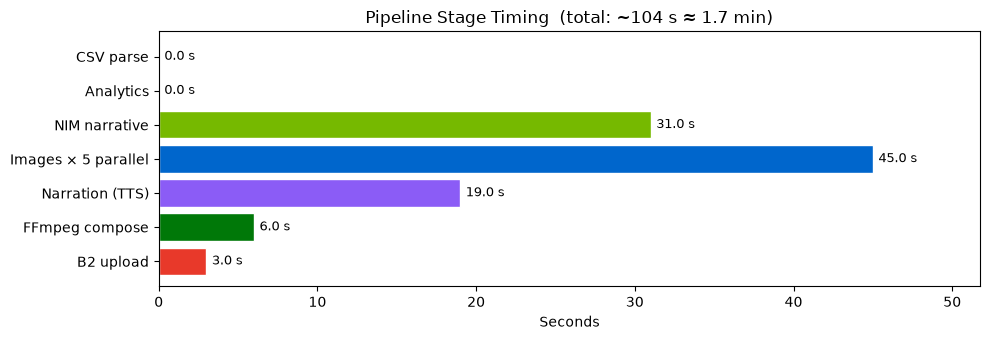

Total: ~104 s  |  Image generation dominates (43% of total)


In [9]:
import matplotlib.pyplot as plt

# Representative timings from a live production run (v1.6.0, 2026-06-29).
# Since v1.6.0 the 5 image generations run in parallel (asyncio.gather + to_thread),
# so the image stage is ~the slowest single image, not the sum of all five.
stages = [
    ("CSV parse",            0.005),
    ("Analytics",            0.001),
    ("NIM narrative",       31.0),
    ("Images × 5 parallel", 45.0),
    ("Narration (TTS)",      19.0),
    ("FFmpeg compose",        6.0),   # segment renders + concat-copy
    ("B2 upload",             3.0),
]

names = [s[0] for s in stages]
times = [s[1] for s in stages]
total = sum(times)

fig, ax = plt.subplots(figsize=(10, 3.5))
bar_colors = ["#009688", "#009688", "#76B900", "#0066CC", "#8B5CF6", "#007808", "#E8392A"]
bars = ax.barh(names, times, color=bar_colors, edgecolor="white")
ax.set_xlabel("Seconds")
ax.set_title(f"Pipeline Stage Timing  (total: ~{total:.0f} s ≈ {total/60:.1f} min)")
ax.bar_label(bars, fmt="%.1f s", padding=4, fontsize=9)
ax.set_xlim(0, max(times) * 1.15)
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(f"Total: ~{total:.0f} s  |  Image generation dominates ({100*times[3]/total:.0f}% of total)")

---
## B2 Artifact Inspection

Shows the full structured artifact layout stored per session in Backblaze B2.  
*Uses whichever scenario completed first: C → B → A.*

In [10]:
result = results.get("demo") or results.get("explorer") or results.get("builder")

if result is None:
    print("Run at least one scenario (A, B, or C) first.")
else:
    session_id = result["session_id"]
    b2_keys    = result["b2_keys"]

    print(f"Session  : {session_id}")
    print(f"Share    : {FRONTEND_URL}/recap/{session_id}")
    print()
    print(f"B2 artifact layout  ({len(b2_keys)} files per session)")
    print("=" * 55)
    for key_name, b2_key in sorted(b2_keys.items()):
        print(f"  {key_name:<12}  {b2_key}")

    print()
    print("session_metadata.json (provenance trail)")
    print("=" * 55)
    print(json.dumps({
        "session_id":         session_id,
        "personality":        result["insights"]["personality"],
        "processing_time_ms": result["processing_time_ms"],
        "artifacts":          len(b2_keys),
        "video_url":          result["video_url"][:60] + "...",
        "share_page":         f"{FRONTEND_URL}/recap/{session_id}",
    }, indent=2))

Session  : 730650b2-deea-423d-adf6-3dd4ac364d8d
Share    : https://bankers-wrapped.vercel.app/recap/730650b2-deea-423d-adf6-3dd4ac364d8d

B2 artifact layout  (14 files per session)
  analytics     abb59f55-b0e0-4e6d-b3f2-0c47151014b7/730650b2-deea-423d-adf6-3dd4ac364d8d/pipeline/analytics.json
  csv           abb59f55-b0e0-4e6d-b3f2-0c47151014b7/730650b2-deea-423d-adf6-3dd4ac364d8d/input/transactions_q4_2025.csv
  generation    abb59f55-b0e0-4e6d-b3f2-0c47151014b7/730650b2-deea-423d-adf6-3dd4ac364d8d/pipeline/generation.json
  metadata      abb59f55-b0e0-4e6d-b3f2-0c47151014b7/730650b2-deea-423d-adf6-3dd4ac364d8d/metadata/session_metadata.json
  narration     abb59f55-b0e0-4e6d-b3f2-0c47151014b7/730650b2-deea-423d-adf6-3dd4ac364d8d/pipeline/narration.mp3
  prompts       abb59f55-b0e0-4e6d-b3f2-0c47151014b7/730650b2-deea-423d-adf6-3dd4ac364d8d/pipeline/prompts.json
  scene_0       abb59f55-b0e0-4e6d-b3f2-0c47151014b7/730650b2-deea-423d-adf6-3dd4ac364d8d/pipeline/scenes/scene_00.jpg
  sc

---
## Summary

| Scenario | What it shows |
| --- | --- |
| A — Financial Builder | Full pipeline run · Jan 2026 CSV · amber theme |
| B — Financial Explorer | Full pipeline run · Q4 2025 CSV · teal theme |
| C — Demo session | Pre-generated session fetched from B2 · no API cost |
| Comparison chart | Side-by-side metrics across both CSV personalities |
| Timing chart | Where the ~2 min goes (image gen dominates) |
| B2 inspection | 14-file artifact layout stored per session in Backblaze B2 |

**Key takeaway:** upload a CSV, receive a personalised narrated financial recap video in ~2–3 minutes —  
5 AI-generated scenes (generated in parallel), synthesised narration, memory-bounded FFmpeg composition, and 14 files (10 artifact types) stored in Backblaze B2.